In [4]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score 


In [5]:
df = pd.read_parquet("cleaned_data.parquet")
print(df.head())
print(df.info())
print(f"Number of entries in df: {len(df)}")

     Industry    Product_Family     CHF  fill_rate order_date  Customer_id  \
0  Automotive  TF Forming Tools   25.61   0.034615 2023-01-02            1   
1  Automotive  TF Forming Tools   51.84   0.014286 2023-01-02            1   
2  Automotive  TF Forming Tools   55.65   0.090476 2023-01-02            1   
3  Automotive  TF Forming Tools   33.53   0.050000 2023-01-02            1   
4  Automotive  TF Cutting Tools  103.35   0.050000 2023-01-02            1   

   coating_id weekday  
0           1  Monday  
1           1  Monday  
2           2  Monday  
3           2  Monday  
4           3  Monday  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744813 entries, 0 to 744812
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Industry        744813 non-null  category      
 1   Product_Family  744813 non-null  category      
 2   CHF             744813 non-null  float64       
 3   fill_ra

In [6]:
print(df.describe())


                 CHF      fill_rate                     order_date  \
count  744813.000000  744813.000000                         744813   
mean      138.499615       0.593030  2024-02-04 09:00:14.282779904   
min         0.000000       0.000000            2023-01-02 00:00:00   
25%         9.870000       0.005000            2023-07-11 00:00:00   
50%        33.450000       0.015625            2024-02-05 00:00:00   
75%       104.430000       0.050000            2024-08-21 00:00:00   
max     66028.830000    2120.833333            2025-04-01 00:00:00   
std       441.751625      11.186893                            NaN   

         Customer_id     coating_id  
count  744813.000000  744813.000000  
mean      140.794418      16.632954  
min         1.000000       1.000000  
25%        26.000000       3.000000  
50%       106.000000       8.000000  
75%       248.000000      22.000000  
max       376.000000     121.000000  
std       116.116421      23.000620  


Data set df_daily = dataset per orderdate and coating id

In [7]:
import pandas as pd
import numpy as np

# 1. Aggregate raw data per coating_id and day
df_daily = (
    df.groupby(['order_date', 'coating_id'])
      .agg({'fill_rate': 'sum', 'CHF': 'sum', 'Customer_id': 'nunique',
            'Industry': 'first', 'Product_Family': 'first', 'weekday': 'first'})
      .reset_index()
      .rename(columns={'fill_rate': 'target_fill_rate'})
)

# 2. Create time series for each coating_id (ensure every day is present)
# Add 'missing' category to the relevant categorical columns
for col in ['Industry', 'Product_Family', 'weekday']:
    if df_daily[col].dtype.name == 'category':
        df_daily[col] = df_daily[col].cat.add_categories(['missing'])

# Create all dates x coating_ids index as before
all_dates = pd.date_range(df['order_date'].min(), df['order_date'].max())
coating_ids = df['coating_id'].unique()

df_full = (
    pd.MultiIndex.from_product([all_dates, coating_ids], names=['order_date', 'coating_id'])
    .to_frame(index=False)
    .merge(df_daily, how='left', on=['order_date', 'coating_id'])
    .fillna({'target_fill_rate': 0, 'CHF': 0, 'Customer_id': 0, 
             'Industry': 'missing', 'Product_Family': 'missing', 'weekday': 'missing'})
)


# 3. Create target columns for 1, 5, and 14 days ahead
for n in [1, 5, 14]:
    df_full[f'target_sum_{n}d'] = (
        df_full.groupby('coating_id')['target_fill_rate']
        .transform(lambda x: x.shift(-n).rolling(n, min_periods=1).sum())
    )

# Now df_full contains:
# - Each date + coating_id pair (even if fill_rate is 0 that day)
# - target_sum_1d: sum of fill_rate for next day (i.e., t+1)
# - target_sum_5d: sum for next 5 days (t+1 to t+5)
# - target_sum_14d: sum for next 14 days (t+1 to t+14)

df_full.head()


,order_date,coating_id,target_fill_rate,CHF,Customer_id,Industry,Product_Family,weekday,target_sum_1d,target_sum_5d,target_sum_14d
0,2023-01-02,1,0.610664,4416.31,7.0,Automotive,TF Forming Tools,Monday,35.836608,0.0,87.775831
1,2023-01-02,2,0.460979,530.76,6.0,Automotive,TF Forming Tools,Monday,2.054886,0.0,0.704194
2,2023-01-02,3,110.434116,30094.88,39.0,Automotive,TF Cutting Tools,Monday,131.054228,0.0,128.597466
3,2023-01-02,4,12.186346,1943.92,5.0,Automotive,TF Forming Tools,Monday,0.391442,0.0,0.328313
4,2023-01-02,5,1.033323,4120.17,6.0,Automotive,TF Cutting Tools,Monday,1.935882,0.0,1.830833


to do - weekday, industry and product_family codieren (die categorical variables)

FEATURE ENGINEERING

Customer/Industry/Product Family:
Number of unique, the most common value, and share of the dominant.
Lag Features:
How much was ordered 1, 2, 7 days ago for this coating_id.
Rolling Window Features:
Demand trends for each coating_id (last 7/14 days).
Calendar Features:
Weekday.
Order Stats:
Number of orders, customers, industries, product families per group.
Everything stays interpretable for time-based modeling and you keep the full signal of your dataset.

In [8]:
import pandas as pd
import numpy as np

# 1. Aggregate engineered features from original df
agg = df.groupby(['order_date', 'coating_id']).agg(
    target_fill_rate=('fill_rate', 'sum'),
    total_chf=('CHF', 'sum'),
    num_orders=('fill_rate', 'count'),
    num_customers=('Customer_id', 'nunique'),
    num_industries=('Industry', 'nunique'),
    num_product_families=('Product_Family', 'nunique'),
    main_industry=('Industry', lambda x: x.value_counts().idxmax()),
    main_product_family=('Product_Family', lambda x: x.value_counts().idxmax()),
    main_customer_id=('Customer_id', lambda x: x.value_counts().idxmax()),
    main_customer_share=('Customer_id', lambda x: x.value_counts().max() / x.size)
).reset_index()

# Add weekday as a numeric feature (avoid name collision)
agg['weekday_num'] = pd.to_datetime(agg['order_date']).dt.weekday

# Rolling features per coating_id
agg = agg.sort_values(['coating_id', 'order_date'])

for lag in [1, 2, 7]:
    agg[f'lag_{lag}_fill_rate'] = (
        agg.groupby('coating_id')['target_fill_rate'].shift(lag).fillna(0)
    )
    agg[f'lag_{lag}_num_orders'] = (
        agg.groupby('coating_id')['num_orders'].shift(lag).fillna(0)
    )
    agg[f'lag_{lag}_num_customers'] = (
        agg.groupby('coating_id')['num_customers'].shift(lag).fillna(0)
    )

for window in [7, 14]:
    agg[f'roll_sum_{window}d'] = (
        agg.groupby('coating_id')['target_fill_rate']
        .shift(1)
        .rolling(window, min_periods=1).sum().reset_index(level=0, drop=True)
    )
    agg[f'roll_mean_{window}d'] = (
        agg.groupby('coating_id')['target_fill_rate']
        .shift(1)
        .rolling(window, min_periods=1).mean().reset_index(level=0, drop=True)
    )

# Merge engineered features into your df_full (daily all combinations matrix)
df_model = pd.merge(
    df_full,
    agg.drop(columns=['target_fill_rate']),  # already present in df_full
    on=['order_date', 'coating_id'],
    how='left'
)

# List of feature columns to fill
feature_cols = [
    'total_chf', 'num_orders', 'num_customers', 'num_industries', 'num_product_families',
    'main_industry', 'main_product_family', 'main_customer_id', 'main_customer_share',
    'weekday_num'
] + [f'lag_{l}_fill_rate' for l in [1,2,7]] + \
    [f'lag_{l}_num_orders' for l in [1,2,7]] + \
    [f'lag_{l}_num_customers' for l in [1,2,7]] + \
    [f'roll_sum_{w}d' for w in [7,14]] + [f'roll_mean_{w}d' for w in [7,14]]

# Fill any remaining NaNs (e.g. at time series start)
for col in feature_cols:
    if col in df_model.columns:
        if pd.api.types.is_categorical_dtype(df_model[col]):
            if 'missing' not in df_model[col].cat.categories:
                df_model[col] = df_model[col].cat.add_categories(['missing'])
            df_model[col] = df_model[col].fillna('missing')
        elif str(df_model[col].dtype) == 'O':  # object type
            df_model[col] = df_model[col].fillna('missing')
        else:
            df_model[col] = df_model[col].fillna(0)


# Preview engineered features
display(df_model[[
    'order_date', 'coating_id', 'target_fill_rate', 'CHF', 'Customer_id', 'Industry', 'Product_Family', 'weekday',  # from df_full
    *feature_cols
]].head())


/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_55045/3940890514.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df_model[col]):


,order_date,coating_id,target_fill_rate,CHF,Customer_id,Industry,Product_Family,weekday,total_chf,num_orders,...,lag_1_num_orders,lag_2_num_orders,lag_7_num_orders,lag_1_num_customers,lag_2_num_customers,lag_7_num_customers,roll_sum_7d,roll_sum_14d,roll_mean_7d,roll_mean_14d
0,2023-01-02,1,0.610664,4416.31,7.0,Automotive,TF Forming Tools,Monday,4416.31,53.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,2023-01-02,2,0.460979,530.76,6.0,Automotive,TF Forming Tools,Monday,530.76,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.610664,0.610664,0.610664,0.610664
2,2023-01-02,3,110.434116,30094.88,39.0,Automotive,TF Cutting Tools,Monday,30094.88,250.0,...,0.0,0.0,0.0,0.0,0.0,0.0,36.447272,36.447272,18.223636,18.223636
3,2023-01-02,4,12.186346,1943.92,5.0,Automotive,TF Forming Tools,Monday,1943.92,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,46.028521,46.028521,15.342840,15.342840
4,2023-01-02,5,1.033323,4120.17,6.0,Automotive,TF Cutting Tools,Monday,4120.17,37.0,...,0.0,0.0,0.0,0.0,0.0,0.0,73.840602,73.840602,18.460151,18.460151


The newly generated column names: 

In [9]:
# Display all column names in the DataFrame
print("Column Names:")
print(df_model.columns.tolist())

Column Names:
['order_date', 'coating_id', 'target_fill_rate', 'CHF', 'Customer_id', 'Industry', 'Product_Family', 'weekday', 'target_sum_1d', 'target_sum_5d', 'target_sum_14d', 'total_chf', 'num_orders', 'num_customers', 'num_industries', 'num_product_families', 'main_industry', 'main_product_family', 'main_customer_id', 'main_customer_share', 'weekday_num', 'lag_1_fill_rate', 'lag_1_num_orders', 'lag_1_num_customers', 'lag_2_fill_rate', 'lag_2_num_orders', 'lag_2_num_customers', 'lag_7_fill_rate', 'lag_7_num_orders', 'lag_7_num_customers', 'roll_sum_7d', 'roll_mean_7d', 'roll_sum_14d', 'roll_mean_14d']



Base Columns
order_date
The calendar day (date) for this aggregated record.
coating_id
The identifier for the coating type; each machine batch can only process one coating_id at a time.
target_fill_rate
The sum of fill_rate for all orders with this coating_id on this date.
This is the realized/historical fill rate — it’s your “truth” (what actually happened) for supervised learning.
CHF
The sum of CHF (Swiss Francs, presumably revenue or cost) for this group on this day.
Customer_id
The first customer_id for this group on this day. (Probably not meaningful; you can ignore for modeling.)
Industry
The first industry for this group on this day. (See above; mainly useful for label or reference, not modeling.)
Product_Family
The first product_family for this group on this day. (Ditto.)
weekday
The day of the week as a string (e.g., ‘Monday’).
Useful for exploratory analysis or for mapping to numeric features.
Prediction Targets
target_sum_1d
The sum of fill_rate for this coating_id for the next day (t+1).
This is the target you’ll train your model to predict for “1-day ahead” forecast.
target_sum_5d
The sum of fill_rate for this coating_id for the next 5 days (t+1 to t+5).
Use this if you want to predict cumulative fill_rate for a 5-day batch window.
target_sum_14d
The sum of fill_rate for this coating_id for the next 14 days (t+1 to t+14).
Engineered Features (Aggregates & Diversity Stats)
total_chf
The sum of CHF for all orders with this coating_id on this day.
num_orders
Number of order lines for this coating_id on this day (total rows aggregated into this group).
num_customers
Number of unique customers who ordered this coating_id on this day.
num_industries
Number of unique industries that placed an order for this coating_id on this day.
num_product_families
Number of unique product families in the orders for this coating_id on this day.
main_industry
The industry with the most orders for this coating_id on this day (“mode”).
main_product_family
The product family with the most orders for this coating_id on this day (“mode”).
main_customer_id
The customer_id with the most orders for this coating_id on this day (“mode”).
main_customer_share
What percentage of all orders came from the largest customer that day for this coating_id
(e.g. if one customer placed 7 out of 10 orders, this is 0.7).
weekday_num
Day of week as an integer (Monday=0, ..., Sunday=6).
Useful for modeling weekly patterns/seasonality.
Time Series Lag Features
(Historical values of the group in previous days)
22. lag_1_fill_rate
- The sum fill_rate for this coating_id one day before (t-1).

lag_1_num_orders
The number of orders for this coating_id one day before.
lag_1_num_customers
The number of customers for this coating_id one day before.
lag_2_fill_rate
The sum fill_rate for this coating_id two days before (t-2).
lag_2_num_orders
Number of orders two days before.
lag_2_num_customers
Number of customers two days before.
lag_7_fill_rate
The sum fill_rate for this coating_id seven days before (t-7).
Useful for capturing weekly cycles.
lag_7_num_orders
Number of orders seven days before.
lag_7_num_customers
Number of customers seven days before.
Rolling Window Features
(Aggregated stats over previous week(s))
31. roll_sum_7d
- Sum of fill_rate for this coating_id over the previous 7 days (not including today).
- Shows recent demand trend.

roll_mean_7d
Mean fill_rate for this coating_id over the previous 7 days (not including today).
roll_sum_14d
Sum of fill_rate for this coating_id over the previous 14 days (not including today).
roll_mean_14d
Mean fill_rate for this coating_id over the previous 14 days (not including today).

i think we could drop certain columns that only highlight the first entry like Customer_id...
here we could add different feature categories later!!


In [10]:
#columns to drop

Time-Based Train/Test Split and Prepare Data for LightGBM


choose Target

In [11]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Choose your target and features
TARGET = 'target_sum_1d'  # change to 'target_sum_5d' or 'target_sum_14d' as needed

# Remove columns not useful for modeling
cols_to_drop = [
    'order_date', 'target_fill_rate', 'CHF', 'Customer_id', 'Industry', 'Product_Family', 'weekday',
    'target_sum_1d', 'target_sum_5d', 'target_sum_14d'  # remove all targets from features and first entry variables
]

# Features for modeling (all except dropped columns)
features = [c for c in df_model.columns if c not in cols_to_drop]

# Sort by date for time-based split
df_model = df_model.sort_values('order_date')

# Combine all relevant columns (features + target) to check for NaNs
required_cols = features + [TARGET]
df_model_clean = df_model.dropna(subset=required_cols)

# Sort by date for time-based split (repeat since we've changed the DataFrame)
df_model_clean = df_model_clean.sort_values('order_date')

# 80/20 split based on date
dates = df_model_clean['order_date'].unique()
split_idx = int(len(dates) * 0.8)
train_dates = dates[:split_idx]
test_dates = dates[split_idx:]

train_mask = df_model_clean['order_date'].isin(train_dates)
test_mask = df_model_clean['order_date'].isin(test_dates)

X_train = df_model_clean.loc[train_mask, features]
y_train = df_model_clean.loc[train_mask, TARGET]

X_test = df_model_clean.loc[test_mask, features]
y_test = df_model_clean.loc[test_mask, TARGET]

# Encode categorical features as category dtype (if needed)
cat_feats = ['main_industry', 'main_product_family', 'main_customer_id']
for col in cat_feats:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Features used:", features)

# Prepare LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_feats)
lgb_test = lgb.Dataset(X_test, label=y_test, categorical_feature=cat_feats)


Train shape: (23616, 24), Test shape: (5904, 24)
Features used: ['coating_id', 'total_chf', 'num_orders', 'num_customers', 'num_industries', 'num_product_families', 'main_industry', 'main_product_family', 'main_customer_id', 'main_customer_share', 'weekday_num', 'lag_1_fill_rate', 'lag_1_num_orders', 'lag_1_num_customers', 'lag_2_fill_rate', 'lag_2_num_orders', 'lag_2_num_customers', 'lag_7_fill_rate', 'lag_7_num_orders', 'lag_7_num_customers', 'roll_sum_7d', 'roll_mean_7d', 'roll_sum_14d', 'roll_mean_14d']


Train and Evaluate a LightGBM Model - split importance

Split Feature Importance: This type measures the number of times a feature is used to split the data across all trees in the model. It is useful for identifying which features are most often involved in the decision-making process.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000731 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3929
[LightGBM] [Info] Number of data points in the train set: 23616, number of used features: 24
[LightGBM] [Info] Start training from score 15.459262
Training until validation scores don't improve for 50 rounds
[10]	training's l1: 23.1806	valid_1's l1: 21.6258
[20]	training's l1: 22.0764	valid_1's l1: 20.9295
[30]	training's l1: 21.284	valid_1's l1: 20.528
[40]	training's l1: 20.7577	valid_1's l1: 20.3608
[50]	training's l1: 20.335	valid_1's l1: 20.1825
[60]	training's l1: 20.0458	valid_1's l1: 20.0902
[70]	training's l1: 19.8298	valid_1's l1: 20.0612
[80]	training's l1: 19.6873	valid_1's l1: 20.1026
[90]	training's l1: 19.5539	valid_1's l1: 20.1226
[100]	training's l1: 19.4514	valid_1's l1: 20.1729
[110]	training's l1: 19.3628	valid

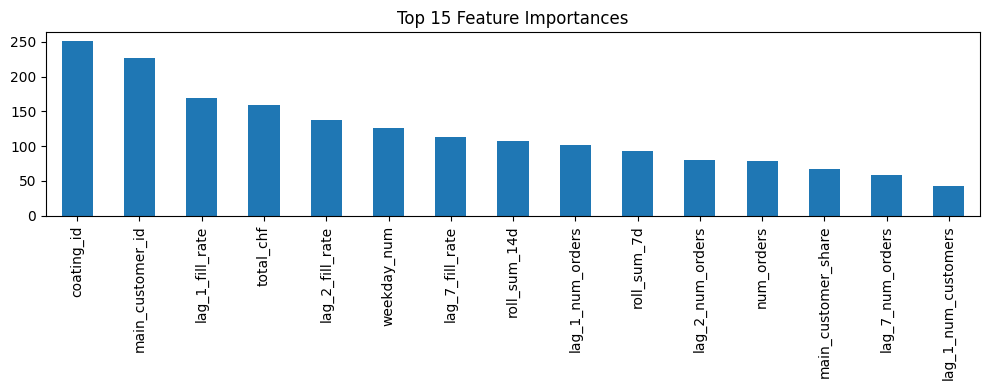

In [12]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

reg = lgb.LGBMRegressor(
    objective='regression',
    metric='mae',
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_estimators=1000
)

# Set up callbacks for early stopping and evaluation logging
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=10)  # print every 10 rounds
]

reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric='mae',
    categorical_feature=cat_feats,
    callbacks=callbacks
)

# Predict and evaluate
y_pred = reg.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {mae:.3f}")

# Feature importances
importances = reg.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
feat_imp.head(15).plot(kind='bar', figsize=(10,4), title='Top 15 Feature Importances')
plt.tight_layout()
plt.show()


Gain - importance Feature ranking

Gain Feature Importance: Gain importance, on the other hand, quantifies the improvement in the model's accuracy achieved by using a particular feature for splitting. 

[LightGBM] [Info] Calculating feature importance by gain...
[LightGBM] [Info] Number of features: 24
[LightGBM] [Info] Top 15 features by gain:
[1] coating_id                Gain: 84519858.99
[2] main_customer_id          Gain: 58847845.79
[3] total_chf                 Gain: 36073300.83
[4] lag_1_fill_rate           Gain: 32585416.91
[5] lag_1_num_orders          Gain: 26491487.20
[6] lag_7_fill_rate           Gain: 25223862.11
[7] weekday_num               Gain: 24979190.12
[8] lag_2_fill_rate           Gain: 24560326.28
[9] lag_2_num_orders          Gain: 24013913.61
[10] num_orders                Gain: 22743123.90
[11] roll_sum_14d              Gain: 16759886.20
[12] roll_sum_7d               Gain: 16581382.78
[13] main_customer_share       Gain: 14363489.61
[14] lag_7_num_orders          Gain: 11497581.09
[15] lag_2_num_customers       Gain: 10965201.40


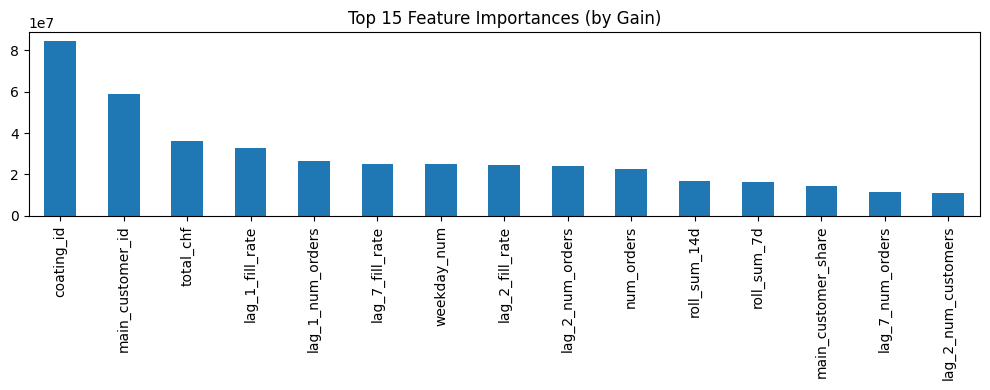

In [15]:
print("[LightGBM] [Info] Calculating feature importance by gain...")

gain_importance = reg.booster_.feature_importance(importance_type='gain')
gain_feat_imp = pd.Series(gain_importance, index=X_train.columns).sort_values(ascending=False)

print(f"[LightGBM] [Info] Number of features: {len(gain_feat_imp)}")
print("[LightGBM] [Info] Top 15 features by gain:")
for i, (feat, imp) in enumerate(gain_feat_imp.head(15).items(), 1):
    print(f"[{i}] {feat:<25} Gain: {imp:.2f}")

gain_feat_imp.head(15).plot(kind='bar', figsize=(10, 4), title='Top 15 Feature Importances (by Gain)')
plt.tight_layout()
plt.show()



feature importance by permutation

Permutation Importance (ΔMAE)
This tells you:

How much worse the model gets when you shuffle a feature, breaking its predictive relationship.
Example:

Shuffling main_customer_id increases MAE by 5.6 → it's critical to predictive performance.

[LightGBM] [Info] Calculating permutation importance using negative MAE...
[LightGBM] [Info] Number of features: 24
[LightGBM] [Info] Top 15 features by permutation drop:
[1] main_customer_id          ΔMAE: 5.6139
[2] lag_1_fill_rate           ΔMAE: 3.0013
[3] lag_7_fill_rate           ΔMAE: 2.6895
[4] coating_id                ΔMAE: 2.2272
[5] total_chf                 ΔMAE: 2.0445
[6] weekday_num               ΔMAE: 1.0188
[7] num_orders                ΔMAE: 0.8224
[8] lag_2_fill_rate           ΔMAE: 0.6600
[9] main_customer_share       ΔMAE: 0.3279
[10] lag_1_num_orders          ΔMAE: 0.2715
[11] lag_7_num_orders          ΔMAE: 0.2586
[12] roll_sum_14d              ΔMAE: 0.2448
[13] lag_2_num_orders          ΔMAE: 0.2379
[14] lag_2_num_customers       ΔMAE: 0.1550
[15] num_industries            ΔMAE: 0.0733


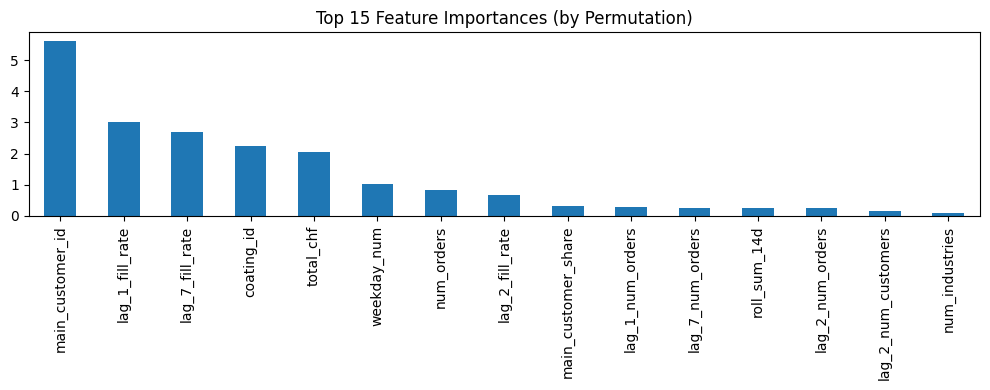

In [16]:
from sklearn.inspection import permutation_importance

print("[LightGBM] [Info] Calculating permutation importance using negative MAE...")

perm_importance = permutation_importance(
    reg, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

perm_feat_imp = pd.Series(perm_importance.importances_mean, index=X_test.columns).sort_values(ascending=False)

print(f"[LightGBM] [Info] Number of features: {len(perm_feat_imp)}")
print("[LightGBM] [Info] Top 15 features by permutation drop:")
for i, (feat, imp) in enumerate(perm_feat_imp.head(15).items(), 1):
    print(f"[{i}] {feat:<25} ΔMAE: {imp:.4f}")

perm_feat_imp.head(15).plot(kind='bar', figsize=(10, 4), title='Top 15 Feature Importances (by Permutation)')
plt.tight_layout()
plt.show()


sdaf

In [11]:
print(lgb.__version__)
help(reg.fit)


4.6.0
Help on method fit in module lightgbm.sklearn:

fit(
    X: Union[lightgbm.compat.dt_DataTable, List[Union[List[float], List[int]]], numpy.ndarray, pandas.core.frame.DataFrame, scipy.sparse._matrix.spmatrix],
    y: Union[List[float], List[int], numpy.ndarray, pandas.core.series.Series, pandas.core.frame.DataFrame, pyarrow.lib.Array, pyarrow.lib.ChunkedArray],
    sample_weight: Union[List[float], List[int], numpy.ndarray, pandas.core.series.Series, pyarrow.lib.Array, pyarrow.lib.ChunkedArray, NoneType] = None,
    init_score: Union[List[float], List[List[float]], numpy.ndarray, pandas.core.series.Series, pandas.core.frame.DataFrame, pyarrow.lib.Table, pyarrow.lib.Array, pyarrow.lib.ChunkedArray, NoneType] = None,
    eval_set: Optional[List[Tuple[Union[lightgbm.compat.dt_DataTable, List[Union[List[float], List[int]]], numpy.ndarray, pandas.core.frame.DataFrame, scipy.sparse._matrix.spmatrix], Union[List[float], List[int], numpy.ndarray, pandas.core.series.Series, pandas.core.fra

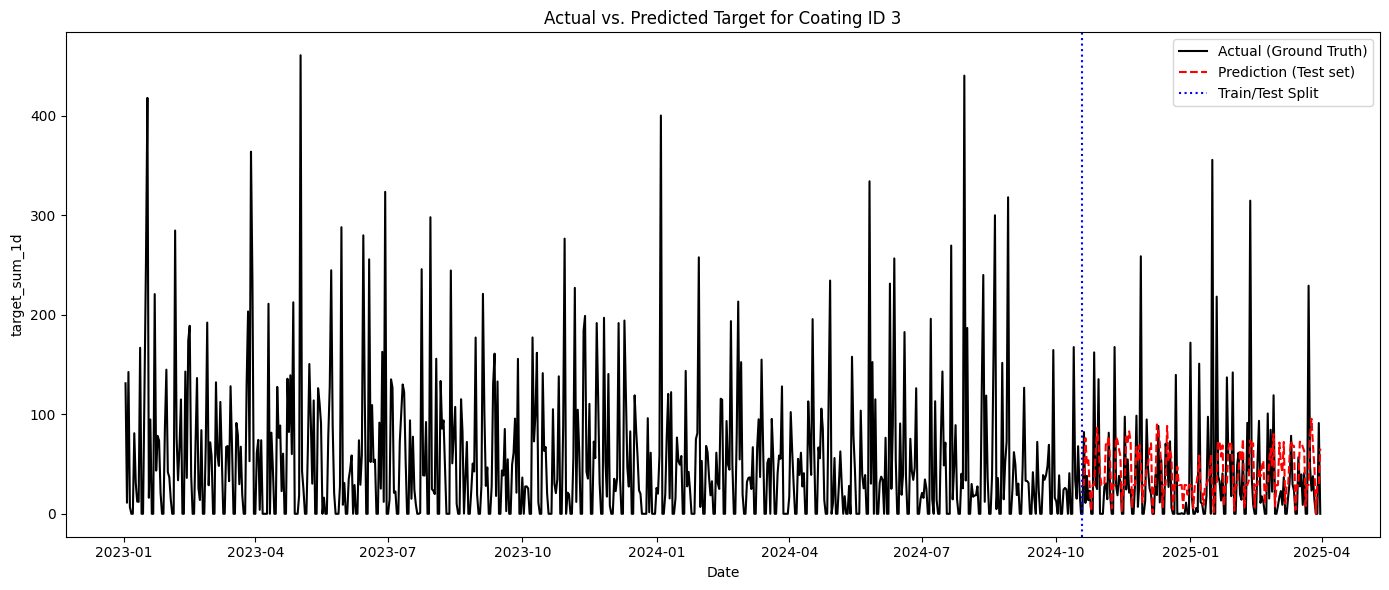

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# ---- Choose coating_id to plot ----
chosen_coating_id = 3

# 1. Filter for this coating_id
df_plot = df_model[df_model['coating_id'] == chosen_coating_id].copy()

# 2. Add a "split" column to know if each row is train or test
df_plot['split'] = 'train'
df_plot.loc[df_plot['order_date'].isin(test_dates), 'split'] = 'test'

# 3. Get actuals for both train and test
df_plot['actual'] = df_plot[TARGET]

# 4. Get predicted values for test set, else NaN
df_plot['pred'] = np.nan
# Ensure test indexes match
# Align categories in df_plot with training set
for col in cat_feats:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].astype(pd.CategoricalDtype(categories=X_train[col].cat.categories))

# Now, safe to predict
test_index = df_plot.index[df_plot['split']=='test']
df_plot.loc[test_index, 'pred'] = reg.predict(df_plot.loc[test_index, features])
# 5. Plot
plt.figure(figsize=(14,6))
plt.plot(df_plot['order_date'], df_plot['actual'], label='Actual (Ground Truth)', color='black')
plt.plot(df_plot[df_plot['split']=='test']['order_date'], df_plot[df_plot['split']=='test']['pred'],
         label='Prediction (Test set)', color='red', linestyle='--')
plt.axvline(df_plot[df_plot['split']=='test']['order_date'].min(), color='blue', linestyle=':', label='Train/Test Split')

plt.title(f'Actual vs. Predicted Target for Coating ID {chosen_coating_id}')
plt.xlabel('Date')
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.show()


Error coating ID 3

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
# Only on test rows with predictions
mask = df_plot['split'] == 'test'
y_true = df_plot.loc[mask, 'actual']
y_pred = df_plot.loc[mask, 'pred']

# Remove any potential NaNs (can happen if you have missing predictions)
mask_valid = ~y_true.isna() & ~y_pred.isna()
y_true = y_true[mask_valid]
y_pred = y_pred[mask_valid]

mae = mean_absolute_error(y_true, y_pred)
# Manual RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Coating ID {chosen_coating_id}:")
print(f"  MAE  = {mae:.3f}")
print(f"  RMSE = {rmse:.3f}")


Coating ID 3:
  MAE  = 39.131
  RMSE = 58.603


For all coating IDs the error

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred)
    # Avoid division by zero
    denominator = np.where(denominator == 0, 1, denominator)
    return np.mean(diff / denominator) * 100

def mape(y_true, y_pred):
    # Avoid division by zero
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan  # or 0, if you prefer
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = []

for coating_id in sorted(df_model['coating_id'].unique()):
    # Filter for coating
    df_c = df_model[df_model['coating_id'] == coating_id].copy()

    # Add split column
    df_c['split'] = 'train'
    df_c.loc[df_c['order_date'].isin(test_dates), 'split'] = 'test'

    # Prepare features for prediction
    for col in cat_feats:
        if col in df_c.columns and col in X_train.columns:
            df_c[col] = df_c[col].astype(pd.CategoricalDtype(categories=X_train[col].cat.categories))
    
    # Only predict on test split
    mask_test = df_c['split'] == 'test'
    df_c['pred'] = np.nan
    if mask_test.sum() == 0:
        continue

    try:
        df_c.loc[mask_test, 'pred'] = reg.predict(df_c.loc[mask_test, features])
    except Exception as e:
        print(f"Skipping coating_id={coating_id}: prediction error: {e}")
        continue

    y_true = df_c.loc[mask_test, TARGET].values
    y_pred = df_c.loc[mask_test, 'pred'].values

    # Remove NaNs
    mask_valid = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask_valid]
    y_pred = y_pred[mask_valid]

    if len(y_true) == 0:
        continue

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    results.append({
        'coating_id': coating_id,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mape': mape_val,
        'smape': smape_val,
        'n_test': len(y_true)
    })

# Collect results in a DataFrame
results_df = pd.DataFrame(results).sort_values('mae')
display(results_df)


,coating_id,mae,rmse,r2,mape,smape,n_test
32,80,3.807007,4.226825,-3.375031e+01,1171.445840,168.440029,164
29,59,3.819245,5.034875,-3.559860e+01,6991.494972,168.882039,164
31,69,3.977601,4.523522,-2.262776e+00,3621.865135,169.137637,164
35,121,4.234405,8.412361,-3.129653e-01,796.776413,121.589956,164
11,13,5.158032,6.046996,-1.499309e+03,187781.188644,198.535343,164
30,68,5.231221,6.586279,-7.161332e-01,15892.642363,175.281424,164
9,10,5.249542,6.128361,-5.550679e+01,9903.259914,187.152699,164
4,5,5.375164,6.692900,-1.762561e+01,2496.041830,157.366645,164
18,24,5.536761,6.511643,-5.259064e+01,25372.192406,165.855461,164
3,4,5.799277,7.388243,-4.254870e+00,9040.499254,179.007154,164


Coating ID 3 two weeks in feb 2025

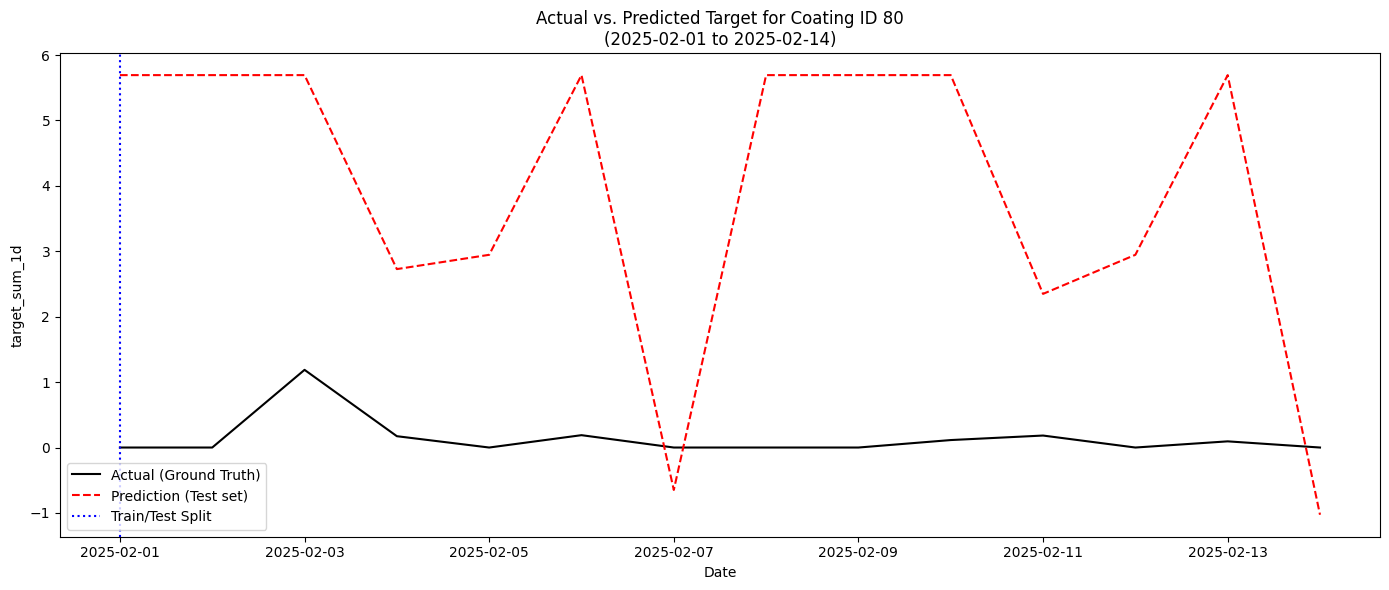

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# ---- Choose coating_id to plot ----
chosen_coating_id = 80

# 1. Filter for this coating_id
df_plot = df_model[df_model['coating_id'] == chosen_coating_id].copy()

# 2. Add a "split" column to know if each row is train or test
df_plot['split'] = 'train'
df_plot.loc[df_plot['order_date'].isin(test_dates), 'split'] = 'test'

# 3. Get actuals for both train and test
df_plot['actual'] = df_plot[TARGET]

# 4. Get predicted values for test set, else NaN
df_plot['pred'] = np.nan
for col in cat_feats:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].astype(pd.CategoricalDtype(categories=X_train[col].cat.categories))
test_index = df_plot.index[df_plot['split']=='test']
df_plot.loc[test_index, 'pred'] = reg.predict(df_plot.loc[test_index, features])

# ---- Zoom for two weeks in Feb 2025 ----
start_date = '2025-02-01'
end_date = '2025-02-14'
mask = (df_plot['order_date'] >= start_date) & (df_plot['order_date'] <= end_date)
df_zoom = df_plot.loc[mask].copy()

plt.figure(figsize=(14,6))
plt.plot(df_zoom['order_date'], df_zoom['actual'], label='Actual (Ground Truth)', color='black')
plt.plot(df_zoom[df_zoom['split']=='test']['order_date'], df_zoom[df_zoom['split']=='test']['pred'],
         label='Prediction (Test set)', color='red', linestyle='--')
if (df_zoom['split'] == 'test').any():
    plt.axvline(df_zoom[df_zoom['split']=='test']['order_date'].min(), color='blue', linestyle=':', label='Train/Test Split')

plt.title(f'Actual vs. Predicted Target for Coating ID {chosen_coating_id}\n({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.show()
